In [3]:
# %%
# CA 49 Roseland — Point 1 pipeline (Python)
# Requires: geopandas, pandas, shapely, requests, matplotlib, contextily (optional for basemaps)

import os
import io
import zipfile
import requests
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import urllib.parse
CENSUS_API_KEY = os.getenv("CENSUS_API_KEY")
import math

In [4]:
CA_PATH = "Community_Areas.zip"

ca = gpd.read_file(f"zip://{CA_PATH}")

# Project to WGS84 
ca = ca.to_crs(4326)

print("Columns:", ca.columns.tolist())
print("Rows:", len(ca))
print("Zip read successfully")

# Detectar el campo con el número de área
if 'area_num_1' in ca.columns:
    ca['area_num'] = ca['area_num_1'].astype(int)
elif 'area_numbe' in ca.columns:
    ca['area_num'] = ca['area_numbe'].astype(int)
else:
    raise ValueError("Couldn't find area number field in CA shapefile")

# Seleccionar las áreas de interés
selected_ids = [16, 49, 70, 76]
selected_names = ca.loc[ca['area_num'].isin(selected_ids), ['area_num', 'community', 'geometry']].copy()

# Comprobar que se han encontrado todas
print("Found:", selected_names['community'].tolist())

# Guardar los GeoDataFrames individuales si los necesitas luego
irving = selected_names[selected_names['area_num'] == 16].copy()
roseland = selected_names[selected_names['area_num'] == 49].copy()
ashburn = selected_names[selected_names['area_num'] == 70].copy()
share = selected_names[selected_names['area_num'] == 76].copy()  # "Share" parece que se refiere a Chatham

# También puedes crear una unión de todos directamente
neighborhoods = gpd.GeoDataFrame(
    pd.concat([irving, roseland, ashburn, share], ignore_index=True),
    crs=ca.crs
)


Columns: ['area_numbe', 'community', 'area_num_1', 'shape_area', 'shape_len', 'geometry']
Rows: 77
Zip read successfully
Found: ['IRVING PARK', 'ROSELAND', 'ASHBURN', 'OHARE']


In [5]:
import requests, zipfile, io, geopandas as gpd, tempfile, os

def read_zipped_shapefile(url: str) -> gpd.GeoDataFrame:
    """
    Download a ZIP shapefile from a URL, save it temporarily,
    and load it as a GeoDataFrame.
    """
    print(f"  Downloading shapefile from {url} ...")
    r = requests.get(url)
    r.raise_for_status()

    # Create a temporary directory to store the zip
    with tempfile.TemporaryDirectory() as tmpdir:
        zip_path = os.path.join(tmpdir, "temp.zip")
        with open(zip_path, "wb") as f:
            f.write(r.content)

        # Read directly from the saved zip
        gdf = gpd.read_file(f"zip://{zip_path}")
        print(f" Loaded shapefile with {len(gdf)} rows and {len(gdf.columns)} columns.")
        return gdf



In [6]:
import geopandas as gpd
import pandas as pd
import json

# ---------------------------
# 1) Archivos GeoJSON de las 4 Community Areas
# ---------------------------
geojson_files = [
    "ohare_60bg_v2.geojson",
    "Roseland-CA49/roseland_blockgroups.geojson",
    "Ashburn_blockgroups.geojson",
    "irving_blockgroups.geojson"
]

# ---------------------------
# 2) Función auxiliar: intentar leer un GeoJSON y reparar si está truncado
# ---------------------------
def safe_read_geojson(path):
    """
    Lee un archivo GeoJSON. Si está truncado, intenta repararlo cerrando corchetes faltantes.
    Devuelve un GeoDataFrame.
    """
    try:
        return gpd.read_file(path)
    except Exception as e:
        print(f"⚠️ Error al leer {path}: {e}")
        print("Intentando reparar el archivo...")

        # Leer como texto para detectar truncamiento
        with open(path, "r", encoding="utf-8") as f:
            text = f.read().strip()

        # Reparación simple: asegurar que termina con los cierres correctos
        if not text.endswith("]}"):
            if text.endswith("]"):
                text += "}"
            elif text.endswith("}"):
                text = text[:-1] + "]}"
            else:
                text += "]}"

        # Guardar una versión reparada temporal
        repaired_path = path.replace(".geojson", "_repaired.geojson")
        with open(repaired_path, "w", encoding="utf-8") as f:
            f.write(text)

        print(f"Guardado archivo reparado: {repaired_path}")
        try:
            return gpd.read_file(repaired_path)
        except Exception as e2:
            print(f"❌ No se pudo reparar {path}: {e2}")
            return None

# ---------------------------
# 3) Leer y combinar todos los block groups
# ---------------------------
bg_list = []
for file in geojson_files:
    gdf = safe_read_geojson(file)
    if gdf is not None and len(gdf) > 0:
        gdf['source_area'] = file.split('/')[-1].replace('_blockgroups.geojson', '')
        gdf['GEOID'] = gdf['GEOID'].astype(str).str.zfill(12)
        bg_list.append(gdf)
    else:
        print(f"⚠️ {file} vacío o ilegible, omitido.")

# ---------------------------
# 4) Unir todos en un solo GeoDataFrame
# ---------------------------
if len(bg_list) == 0:
    raise ValueError("Ningún GeoJSON válido encontrado. Revisa los archivos de entrada.")

bg_all = gpd.GeoDataFrame(pd.concat(bg_list, ignore_index=True), crs=bg_list[0].crs)

# ---------------------------
# 5) Extraer GEOID únicos y guardar el combinado
# ---------------------------
bg_ids = sorted(bg_all['GEOID'].unique().tolist())
print(f"✅ Total unique block groups across 4 CAs: {len(bg_ids)}")

bg_all.to_file("Combined_4CA_blockgroups.geojson", driver="GeoJSON")
print("✅ Archivo combinado guardado como: Combined_4CA_blockgroups.geojson")

# ---------------------------
# 6) (Opcional) Vista previa rápida
# ---------------------------
print(bg_all[['source_area', 'GEOID']].head())
# bg_all.plot(column='source_area', legend=True)


✅ Total unique block groups across 4 CAs: 260
✅ Archivo combinado guardado como: Combined_4CA_blockgroups.geojson
             source_area         GEOID
0  ohare_60bg_v2.geojson  170311705004
1  ohare_60bg_v2.geojson  170311705003
2  ohare_60bg_v2.geojson  170317706023
3  ohare_60bg_v2.geojson  170317608021
4  ohare_60bg_v2.geojson  170317705002


In [7]:
import pandas as pd

# ---------------------------
# 2) Load ACS data and combine for 4 Community Areas
# ---------------------------

# Lista de CSVs de cada CA
csv_files = [
    "acs_blockgroups_all_years2010-2023_roseland.csv",
    "acs_blockgroups_all_years2013-2023_asburn.csv",
    "acs_blockgroups_all_years2013-2023_ohare.csv",
    "acs_blockgroups_all_years2013-2023_irving.csv"
]

# Cargar y concatenar todas las CA
dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    df['source_area'] = file.split('_')[-1].replace('.csv', '')  # marca de origen opcional
    df['GEOID'] = df['GEOID'].astype(str).str.zfill(12)
    dfs.append(df)

# Unir todas las tablas
df_all = pd.concat(dfs, ignore_index=True)

# Filtrar por año más reciente (2023)
df_latest = df_all[df_all['year'] == 2023].copy()

# Filtrar solo los block groups que están dentro de las 4 áreas (bg_ids viene del paso anterior)
df_selected = df_latest[df_latest['GEOID'].isin(bg_ids)].copy()

print(f"Total block groups (2023, 4 CAs): {len(df_selected)}")
print(df_selected['source_area'].value_counts())

# Opcional: revisar algunas columnas
print(df_selected.head())


Total block groups (2023, 4 CAs): 233
source_area
irving      69
roseland    66
asburn      65
ohare       33
Name: count, dtype: int64
                                                  NAME  B01003_001E  \
639  Block Group 1; Census Tract 4912; Cook County;...          560   
640  Block Group 2; Census Tract 4912; Cook County;...          611   
641  Block Group 3; Census Tract 4912; Cook County;...          561   
642  Block Group 2; Census Tract 4913; Cook County;...          637   
643  Block Group 3; Census Tract 4913; Cook County;...          409   

     B01002_001E  B02001_001E  B02001_003E  B03003_001E  B03003_003E  \
639         32.7          560          535          560            0   
640         69.6          611          551          611           51   
641         37.5          561          549          561            2   
642         29.4          637          499          637          133   
643         27.5          409          409          409            0   

    

In [8]:
# ---------------------------
# 3) Compute derived socioeconomic indicators
# ---------------------------
df_selected['unemp_rate'] = df_selected['B23025_005E'] / df_selected['B23025_003E']
df_selected['owner_share'] = df_selected['B25003_002E'] / df_selected['B25003_001E']
df_selected['vacancy_rate'] = df_selected['B25002_003E'] / df_selected['B25002_001E']
df_selected['pct_black'] = df_selected['B02001_003E'] / df_selected['B02001_001E']




In [9]:

# ---------------------------
# 4) Select features for scaling
# ---------------------------
features = [
    'B19013_001E',   # Median income
    'unemp_rate',
    'owner_share',
    'vacancy_rate',
    'pct_black',
    'B01002_001E'    # Median age
]

from sklearn.preprocessing import StandardScaler

X = df_selected[features].astype(float).fillna(0)
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=features,
    index=df_selected['GEOID']
)

print("Scaled matrix shape:", X_scaled.shape)
X_scaled.head()

Scaled matrix shape: (233, 6)


,B19013_001E,unemp_rate,owner_share,vacancy_rate,pct_black,B01002_001E
GEOID,,,,,,
170314912001,0.346518,2.763307,-0.135325,2.685389,1.350348,0.065653
170314912002,0.346619,0.079306,0.760081,-0.840425,1.223241,0.065654
170314912003,0.346609,-0.597082,0.388900,1.659525,1.405533,0.065653
170314913002,0.346534,2.733571,-0.161286,0.959627,0.942143,0.065653
170314913003,0.346575,-0.721379,-1.182395,2.352842,1.456299,0.065653


In [10]:
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx

sim_matrix = cosine_similarity(X_scaled)
G = nx.Graph()

# Add nodes with attributes
for geoid, row in df_selected.iterrows():
    G.add_node(row['GEOID'], **row.to_dict())

# Add edges above a similarity threshold
threshold = 0.75  # adjust for density
for i in range(len(sim_matrix)):
    for j in range(i + 1, len(sim_matrix)):
        if sim_matrix[i, j] > threshold:
            G.add_edge(df_selected.iloc[i]['GEOID'],
                       df_selected.iloc[j]['GEOID'],
                       weight=sim_matrix[i, j])

print(f"Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")


Graph built: 233 nodes, 3237 edges


In [11]:
import networkx as nx

# Basic metrics
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)
avg_clustering = nx.average_clustering(G)
components = nx.number_connected_components(G)

print(f"Nodes: {num_nodes}, Edges: {num_edges}")
print(f"Density: {density:.3f}, Avg Clustering: {avg_clustering:.3f}, Connected Components: {components}")


Nodes: 233, Edges: 3237
Density: 0.120, Avg Clustering: 0.670, Connected Components: 2


In [12]:
from networkx.algorithms import community

communities = community.greedy_modularity_communities(G, weight='weight')

# Assign community labels to nodes
for i, c in enumerate(communities):
    for node in c:
        G.nodes[node]['community'] = i

print(f"Detected {len(communities)} socioeconomic clusters.")


Detected 5 socioeconomic clusters.


In [13]:
import pandas as pd

df_selected['community'] = df_selected['GEOID'].map(nx.get_node_attributes(G, 'community'))
summary = df_selected.groupby('community')[features].mean()
print(summary)

            B19013_001E  unemp_rate  owner_share  vacancy_rate  pct_black  \
community                                                                   
0          6.207027e+04    0.146271     0.630794      0.146699   0.897498   
1          8.414352e+04    0.061224     0.436521      0.070564   0.041573   
2          9.780888e+04    0.074665     0.854227      0.026669   0.100147   
3         -6.666667e+08    0.135125     0.675233      0.118654   0.555020   
4         -6.666667e+08         NaN          NaN           NaN        NaN   

            B01002_001E  
community                
0          4.185467e+01  
1          3.901791e+01  
2          3.854697e+01  
3          4.213333e+01  
4         -6.666667e+08  


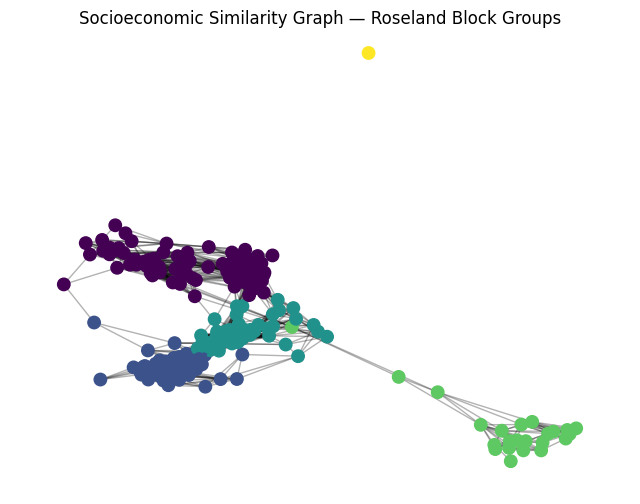

In [14]:
import matplotlib.pyplot as plt

# The graph (network) shows how block groups are connected based on cosine similarity across key socioeconomic variables
# (income, unemployment, vacancy, homeownership, age, race composition). Each node is a block group, and edges link highly similar ones.

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42, weight='weight')
colors = [G.nodes[n]['community'] for n in G.nodes]
nx.draw_networkx_nodes(G, pos, node_color=colors, cmap='viridis', node_size=80)
nx.draw_networkx_edges(G, pos, alpha=0.3)
plt.title("Socioeconomic Similarity Graph — Roseland Block Groups")
plt.axis('off')
plt.show()


In [15]:
components = list(nx.connected_components(G))
print(f"{len(components)} connected components")

# Largest component size
largest = max(components, key=len)
print(f"Largest component: {len(largest)} nodes")


2 connected components
Largest component: 232 nodes


In [16]:
import networkx as nx

components = list(nx.connected_components(G))
print(f"Number of connected components: {len(components)}")

# Assign component ID to each node
component_dict = {}
for i, comp in enumerate(components):
    for geoid in comp:
        component_dict[geoid] = i

df_selected['component'] = df_selected['GEOID'].map(component_dict)
print(df_selected['component'].value_counts().head())


Number of connected components: 2
component
0    232
1      1
Name: count, dtype: int64


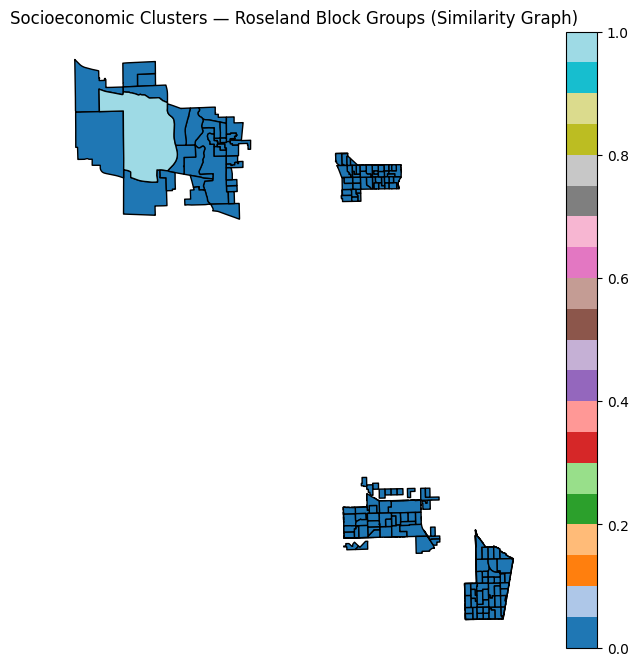

In [17]:
import matplotlib.pyplot as plt

# Asegurar tipos consistentes
df_selected['GEOID'] = df_selected['GEOID'].astype(str)
bg_all['GEOID'] = bg_all['GEOID'].astype(str)

# Merge con geometrías
roseland_map = bg_all.merge(
    df_selected[['GEOID', 'component']],
    on='GEOID',
    how='left'
)

# Visualizar clusters
fig, ax = plt.subplots(figsize=(8, 8))
roseland_map.plot(column='component', cmap='tab20', legend=True, ax=ax, edgecolor='black')

# Dibujar borde del área si lo tienes (opcional)
try:
    roseland.boundary.plot(ax=ax, color='black', linewidth=1)
except:
    pass

ax.set_title("Socioeconomic Clusters — Roseland Block Groups (Similarity Graph)")
ax.axis('off')
plt.show()


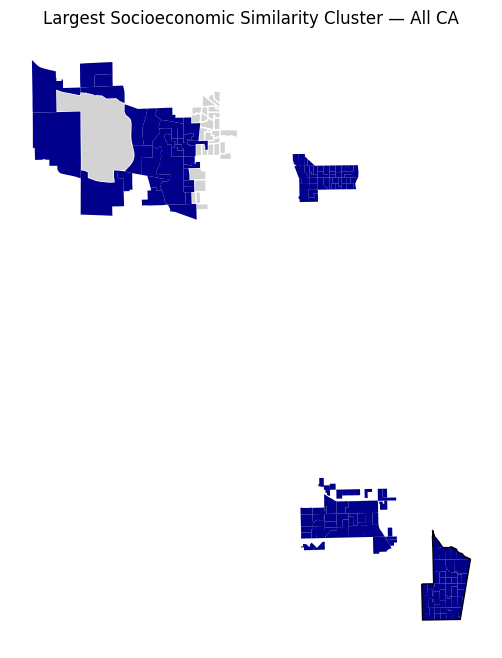

In [18]:
largest = max(components, key=len)
roseland_map['in_largest'] = roseland_map['GEOID'].isin(largest)

# The map isolates the largest connected cluster, representing Roseland’s socioeconomic “core” 
# the contiguous area of block groups that share the most similar economic and demographic conditions.

fig, ax = plt.subplots(figsize=(8, 8))
roseland_map.plot(ax=ax, color='lightgrey', edgecolor='white')
roseland_map[roseland_map['in_largest']].plot(ax=ax, color='darkblue')
roseland.boundary.plot(ax=ax, color='black', linewidth=1)
ax.set_title("Largest Socioeconomic Similarity Cluster — All CA")
ax.axis('off')
plt.show()


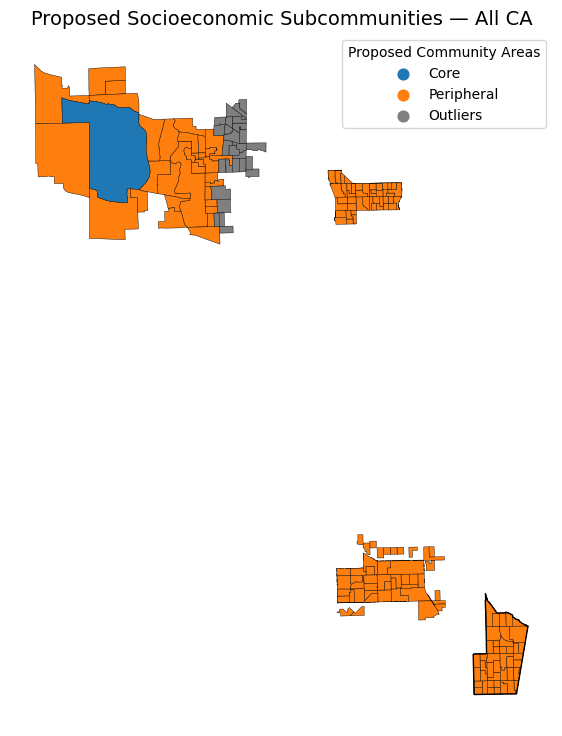

In [20]:
import matplotlib.pyplot as plt

component_to_area = {
    1: "Core",
    0: "Peripheral",
    2: "Outliers"  # por si aparece algún otro componente
}

area_colors = {
    "Core": "#1f77b4",          # dark blue
    "Peripheral": "#ff7f0e",    # orange
    "Outliers": "#7f7f7f"       # gray
}

roseland_map['proposed_area'] = (
    roseland_map['component']
    .map(component_to_area)
    .fillna("Outliers")
)

fig, ax = plt.subplots(figsize=(9, 9))
roseland_map.plot(
    ax=ax,
    color=roseland_map['proposed_area'].map(area_colors),
    edgecolor='black',
    linewidth=0.3
)

roseland.boundary.plot(ax=ax, color='black', linewidth=1)

# Crear leyenda personalizada
for label, color in area_colors.items():
    ax.scatter([], [], c=color, label=label, s=60)
ax.legend(title="Proposed Community Areas", loc="upper right", frameon=True)

ax.set_title("Proposed Socioeconomic Subcommunities — All CA", fontsize=14)
ax.axis('off')
plt.show()
